# Trabajo Práctico 2 - Grupo 02

### Red Neuronal FastText + BiLSTM + Attention — Entrega N11

Integrantes:

*   Bermudez, Agustin
*   Calderón, Tiago
*   Gonzalez Pautaso, Mateo
*   Moreyra, Santiago
*   Nieves, Maylen


**Dataset:** LLM aumentado y balanceado (66.553 reseñas)

**Hiperparámetros:** `max_len=128` | `lstm_units=128/64` | `att_heads=4` | `lr=1e-4` | `phase2_lr=5e-5` | `batch=64` | `dropout=0.3`

**Framework:** PyTorch + HuggingFace Trainer (misma API que BETO v1-v7)

**Mejoras vs diseño original:**
- LR reducida de 2e-4 a 1e-4; dropout reducido (0.2/0.3/0.2).
- Unfreezing progresivo en 2 fases vía Trainer.
- OOV inicializado con distribución normal.
- FastText: intenta `.bin` (subwords), fallback a `.vec.gz` (stdlib).
- Entrenamiento delegado a HuggingFace Trainer (misma API que notebooks BETO).

**Justificación:** Arquitectura distinta a BETO: embeddings estáticos FastText + BiLSTM + Multi-Head Self-Attention con `clean_classical()` (lematización). Compara representaciones estáticas vs. contextuales.


## 1. Instalación de dependencias


In [1]:
# AMD GPU (Radeon 9070 XT) via DirectML
!pip install torch-directml

# PyTorch CPU (si tenés NVIDIA, usa cu124 en vez de cpu)
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu

# HuggingFace Trainer (misma API que las notebooks BETO v1-v7)
!pip install transformers datasets accelerate

# NLP
!pip install spacy
!python -m spacy download es_core_news_sm

# FastText (si falla compilación, la notebook usa fallback .vec.gz)
!pip install fasttext-wheel

# ML, data, viz
!pip install scikit-learn joblib pandas numpy scipy matplotlib seaborn nltk


ERROR: Could not find a version that satisfies the requirement torch-directml (from versions: none)

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch-directml


Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     -------- ------------------------------- 2.6/12.9 MB 17.8 MB/s eta 0:00:01
     ---------------------------------------- 12.9/12.9 MB 37.0 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached fasttext-wheel-0.9.2.tar.gz (71 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
Failed to build fasttext-wheel


  error: subprocess-exited-with-error
  
  × Building wheel for fasttext-wheel (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [85 lines of output]
      C:\Users\agust\AppData\Local\Temp\pip-build-env-7f3w9hut\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
      !!
      
              ********************************************************************************
              Usage of dash-separated 'description-file' will not be supported in future
              versions. Please use the underscore name 'description_file' instead.
              (Affected: fasttext-wheel).
      
              Available configuration options are listed in:
              https://setuptools.pypa.io/en/latest/userguide/declarative_config.html
      
              This deprecation is overdue, please update your project and 


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import nltk
nltk.download("sentiwordnet")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package sentiwordnet to
[nltk_data]     C:\Users\agust\AppData\Roaming\nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\agust\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\agust\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 2. Imports y configuración


In [3]:
import sys
sys.path.insert(0, "../../..")  # TP2/

import os, gzip, gc, urllib.request
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

from sklearn.metrics import f1_score
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

from common.data_utils import get_split, SEED
from common.preprocessing import clean_classical
from common.evaluation import evaluate, CLASS_NAMES

np.random.seed(SEED)
torch.manual_seed(SEED)

# Dispositivo: DirectML (AMD) > CUDA (NVIDIA) > CPU
try:
    import torch_directml
    DEVICE = torch_directml.device()
    DEVICE_NAME = "directml"
    print("Usando DirectML (AMD GPU)")
except ImportError:
    if torch.cuda.is_available():
        DEVICE = torch.device("cuda")
        DEVICE_NAME = "cuda"
        print(f"GPU NVIDIA: {torch.cuda.get_device_name(0)}")
    else:
        DEVICE = torch.device("cpu")
        DEVICE_NAME = "cpu"
        print("Usando CPU")
print(f"Device: {DEVICE}")

# Hiperparámetros
MAX_SEQ_LEN     = 128
MAX_VOCAB_SIZE  = 50_000
EMBEDDING_DIM   = 300
BATCH_SIZE      = 64
LSTM_UNITS_1    = 128
LSTM_UNITS_2    = 64
ATT_HEADS       = 4
DENSE_UNITS     = 128
DROPOUT_RATE    = 0.3
LEARNING_RATE   = 1e-4
PHASE2_LR       = 5e-5
MAX_EPOCHS      = 30
EARLY_PATIENCE  = 5

print(f"Framework: PyTorch {torch.__version__} + Transformers")
print(f"Device: {DEVICE_NAME} | SEED: {SEED}")
print(f"LR: {LEARNING_RATE} (fase 1) | {PHASE2_LR} (fase 2)")


c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Usando CPU
Device: cpu
Framework: PyTorch 2.12.0+cpu + Transformers
Device: cpu | SEED: 42
LR: 0.0001 (fase 1) | 5e-05 (fase 2)


## 3. Carga de datos


In [4]:
train_df = pd.read_csv("../../../data/train_augmented_llm_balanced.csv")
test_df  = pd.read_csv("../../../data/test.csv")

print(f"Train: {len(train_df):,} filas")
print(f"Distribuci\u00f3n:\n{train_df['label'].value_counts().sort_index()}")

X_train_raw, X_val_raw, y_train, y_val = get_split(train_df)

print("\nAplicando clean_classical...")
X_train = [clean_classical(t) for t in X_train_raw]
X_val   = [clean_classical(t) for t in X_val_raw]
X_test  = [clean_classical(t) for t in test_df["text"].values]
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Ejemplo: {X_train[0][:120]}...")


Train: 66,553 filas
Distribución:
label
0    22346
1    21864
2    22343
Name: count, dtype: int64

Aplicando clean_classical...
Train: 53,242 | Val: 13,311 | Test: 8,500
Ejemplo: kit herramienta ser bueno pero no incluir herramienta necesario ser adecuar principiant...


## 4. Vocabulario y embeddings FastText


In [5]:
print("Construyendo vocabulario...")
token_counts = Counter()
for text in X_train:
    token_counts.update(text.split())
print(f"Tokens \u00fanicos en train: {len(token_counts):,}")

most_common = token_counts.most_common(MAX_VOCAB_SIZE - 2)
vocab = {"<PAD>": 0, "<OOV>": 1}
for token, _ in most_common:
    vocab[token] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f"Tama\u00f1o del vocabulario: {VOCAB_SIZE:,}")

# Cargar vectores FastText: intenta .bin (subwords), fallback a .vec.gz (stdlib)
print("\nCargando vectores FastText...")
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM), dtype=np.float32)

# OOV inicializado con distribuci\u00f3n normal
rng = np.random.RandomState(SEED)
embedding_matrix[1] = rng.normal(0, 0.05, EMBEDDING_DIM).astype(np.float32)
print("<OOV> inicializado con N(0, 0.05)")

fasttext_loaded = False
try:
    import fasttext; import fasttext.util
    if not Path("cc.es.300.bin").exists():
        print("Descargando cc.es.300.bin (~7 GB)...")
        fasttext.util.download_model("es", if_exists="ignore")
    print("Cargando FastText .bin...")
    ft_model = fasttext.load_model("cc.es.300.bin")
    print(f"FastText cargado. Dim: {ft_model.get_dimension()}")
    found = 0
    for token, idx in vocab.items():
        if token in ("<PAD>", "<OOV>"): continue
        embedding_matrix[idx] = ft_model.get_word_vector(token).astype(np.float32)
        found += 1
    print(f"Cobertura (.bin): {found/(VOCAB_SIZE-2)*100:.1f}%")
    fasttext_loaded = True
except Exception as e:
    print(f"fasttext no disponible ({type(e).__name__}), usando .vec.gz...")

if not fasttext_loaded:
    VEC = Path("cc.es.300.vec"); VGZ = Path("cc.es.300.vec.gz")
    if not VEC.exists() and not VGZ.exists():
        print("Descargando cc.es.300.vec.gz (~1.2 GB)...")
        urllib.request.urlretrieve(
            "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz",
            str(VGZ))
    if not VEC.exists():
        print("Descomprimiendo...")
        import shutil
        with gzip.open(VGZ, 'rb') as fi:
            with open(VEC, 'wb') as fo: shutil.copyfileobj(fi, fo)
    print(f"Cargando desde {VEC}...")
    found = 0
    with open(VEC, 'r', encoding='utf-8') as f:
        f.readline()
        for line in f:
            parts = line.rstrip().split(' ')
            if parts[0] in vocab:
                v = np.array(parts[1:], dtype=np.float32)
                if len(v) == EMBEDDING_DIM:
                    embedding_matrix[vocab[parts[0]]] = v; found += 1
    print(f"Cobertura (.vec): {found/(VOCAB_SIZE-2)*100:.1f}%")

print(f"Embedding matrix: {embedding_matrix.shape}")
del token_counts, most_common; gc.collect()


Construyendo vocabulario...
Tokens únicos en train: 27,295
Tamaño del vocabulario: 27,297

Cargando vectores FastText...
<OOV> inicializado con N(0, 0.05)
fasttext no disponible (ModuleNotFoundError), usando .vec.gz...
Cargando desde cc.es.300.vec...
Cobertura (.vec): 81.4%
Embedding matrix: (27297, 300)


32

In [6]:
def texts_to_sequences(texts, vocab, max_len):
    seqs = []
    for text in texts:
        tokens = text.split()[:max_len]
        seq = [vocab.get(t, 1) for t in tokens]
        seq += [0] * (max_len - len(seq))
        seqs.append(seq)
    return np.array(seqs, dtype=np.int32)

X_train_seq = texts_to_sequences(X_train, vocab, MAX_SEQ_LEN)
X_val_seq   = texts_to_sequences(X_val,   vocab, MAX_SEQ_LEN)
X_test_seq  = texts_to_sequences(X_test,  vocab, MAX_SEQ_LEN)

print(f"Train: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")
print(f"Label dist train: {np.bincount(y_train.astype(int))}")

# Dataset (Trainer crea DataLoader internamente, no hace falta loader manual)
class ResenasDataset(Dataset):
    def __init__(self, sequences, labels=None):
        self.input_ids = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long) if labels is not None else None
    def __len__(self): return len(self.input_ids)
    def __getitem__(self, idx):
        item = {"input_ids": self.input_ids[idx]}
        if self.labels is not None: item["labels"] = self.labels[idx]
        return item

train_dataset = ResenasDataset(X_train_seq, y_train)
val_dataset   = ResenasDataset(X_val_seq,   y_val)
test_dataset  = ResenasDataset(X_test_seq)


Train: (53242, 128) | Val: (13311, 128) | Test: (8500, 128)
Label dist train: [17877 17491 17874]


## 5. Arquitectura del modelo


In [7]:
class SpatialDropout1D(nn.Module):
    def __init__(self, p=0.2): super().__init__(); self.p = p
    def forward(self, x):
        if not self.training or self.p == 0: return x
        mask = torch.rand(x.size(0), 1, x.size(2), device=x.device) > self.p
        return x * mask.float() / (1 - self.p)


class FastTextBiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix,
                 lstm_units_1=128, lstm_units_2=64, att_heads=4,
                 dense_units=128, dropout_rate=0.3, freeze=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        if freeze: self.embedding.weight.requires_grad = False

        self.spatial_dropout = SpatialDropout1D(0.2)
        self.bilstm1 = nn.LSTM(embedding_dim, lstm_units_1, bidirectional=True, batch_first=True)
        self.ln1 = nn.LayerNorm(lstm_units_1 * 2)
        self.bilstm2 = nn.LSTM(lstm_units_1 * 2, lstm_units_2, bidirectional=True, batch_first=True)
        self.ln2 = nn.LayerNorm(lstm_units_2 * 2)
        self.attention = nn.MultiheadAttention(lstm_units_2 * 2, att_heads, batch_first=True)
        self.ln3 = nn.LayerNorm(lstm_units_2 * 2)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dense1   = nn.Linear(lstm_units_2 * 4, dense_units)
        self.dropout2 = nn.Dropout(0.2)
        self.output   = nn.Linear(dense_units, 3)
        self._init_weights()

    def _init_weights(self):
        for n, p in self.named_parameters():
            if "embedding" in n: continue
            if "weight" in n and p.dim() >= 2: nn.init.xavier_uniform_(p)
            elif "bias" in n: nn.init.zeros_(p)

    def forward(self, input_ids, labels=None):
        pad_mask = (input_ids == 0)

        x = self.embedding(input_ids)
        x = self.spatial_dropout(x)
        x, _ = self.bilstm1(x); x = self.ln1(x)
        x, _ = self.bilstm2(x); x = self.ln2(x)
        a, _ = self.attention(x, x, x); x = self.ln3(x + a)

        m = (~pad_mask).float().unsqueeze(-1)
        avg = (x * m).sum(1) / m.sum(1).clamp(min=1)
        xm = x.clone(); xm[pad_mask] = -1e9
        max_pool = xm.max(1)[0]
        x = torch.cat([avg, max_pool], dim=1)

        x = self.dropout1(x)
        x = F.gelu(self.dense1(x))
        x = self.dropout2(x)
        return {"logits": self.output(x)}


model = FastTextBiLSTMAttention(
    VOCAB_SIZE, EMBEDDING_DIM, embedding_matrix,
    lstm_units_1=LSTM_UNITS_1, lstm_units_2=LSTM_UNITS_2,
    att_heads=ATT_HEADS, dense_units=DENSE_UNITS,
    dropout_rate=DROPOUT_RATE, freeze=True).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Par\u00e1metros: {total:,} total | {trainable:,} entrenables")


Parámetros: 8,894,639 total | 705,539 entrenables


## 6. Entrenamiento (2 fases: congelado → fine-tuning)


In [8]:
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(input_ids=inputs["input_ids"])
        logits = outputs["logits"] if isinstance(outputs, dict) else outputs
        loss = F.cross_entropy(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1_per = f1_score(labels, preds, average=None, zero_division=0)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_neg": float(f1_per[0]),
        "f1_neu": float(f1_per[1]),
        "f1_pos": float(f1_per[2]),
    }

Path("models").mkdir(parents=True, exist_ok=True)

# ======================================================
# FASE 1: Embeddings congelados, cosine_with_restarts
# ======================================================
print("=" * 70)
print("FASE 1: Embeddings congelados (lr=1e-4, cosine_with_restarts)")
print("=" * 70)

training_args1 = TrainingArguments(
    output_dir="models/v11_phase1",
    num_train_epochs=MAX_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine_with_restarts",
    lr_scheduler_kwargs={"num_cycles": 3},
    warmup_ratio=0.1,
    weight_decay=1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    max_grad_norm=1.0,
)

trainer1 = CustomTrainer(
    model=model,
    args=training_args1,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_PATIENCE)],
)

trainer1.train()

# ======================================================
# FASE 2: Unfreezing embeddings, LR más baja
# ======================================================
print("\n" + "=" * 70)
print("FASE 2: Fine-tuning FastText (lr=5e-5, reduce_lr_on_plateau)")
print("=" * 70)

model.embedding.weight.requires_grad = True
print(f"Parámetros entrenables ahora: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

training_args2 = TrainingArguments(
    output_dir="models/v11_phase2",
    num_train_epochs=10,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=PHASE2_LR,
    lr_scheduler_type="reduce_lr_on_plateau",
    lr_scheduler_kwargs={"mode": "max", "factor": 0.5, "patience": 2},
    warmup_ratio=0.1,
    weight_decay=1e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    max_grad_norm=1.0,
)

trainer2 = CustomTrainer(
    model=model,
    args=training_args2,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer2.train()

print("\nEntrenamiento completo (Fase 1 + Fase 2).")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


FASE 1: Embeddings congelados (lr=1e-4, cosine_with_restarts)


c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Neg,F1 Neu,F1 Pos
1,1.165278,0.755053,0.674916,0.694360,0.653842,0.676548
2,0.747875,0.632621,0.734738,0.746545,0.695652,0.762018
3,0.686670,0.590799,0.751213,0.766225,0.698917,0.788496
4,0.623026,0.565290,0.764560,0.778424,0.714411,0.800843
5,0.588453,0.546482,0.771518,0.789181,0.717903,0.807471
6,0.568925,0.528655,0.777561,0.796439,0.714550,0.821694
7,0.551981,0.534333,0.774142,0.790840,0.718020,0.813566
8,0.539231,0.523833,0.779418,0.797830,0.721998,0.818426
9,0.530809,0.516831,0.779993,0.799746,0.719267,0.820964
10,0.522735,0.520398,0.778720,0.798131,0.720010,0.818018


c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(


FASE 2: Fine-tuning FastText (lr=5e-5, reduce_lr_on_plateau)
Parámetros entrenables ahora: 8,894,639


c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Neg,F1 Neu,F1 Pos
1,0.479946,0.500653,0.792550,0.816012,0.726702,0.834936
2,0.445473,0.504102,0.794040,0.814354,0.729466,0.838302
3,0.421281,0.515692,0.794944,0.815756,0.731108,0.837969
4,0.386890,0.534850,0.790117,0.811784,0.726044,0.832524
5,0.362157,0.539815,0.789363,0.808004,0.725708,0.834375
6,0.341827,0.564397,0.790806,0.809952,0.728054,0.834411


c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(


Entrenamiento completo (Fase 1 + Fase 2).


## 7. Evaluación en validación


In [9]:
preds_output = trainer2.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

evaluate(
    "red_neuronal_fasttext_bilstm_attention_v11",
    y_val, y_pred,
    hyperparams={
        "model": "FastText + BiLSTM(128/64) + MultiHeadAttention(4)",
        "framework": f"PyTorch {torch.__version__} + Transformers",
        "device": DEVICE_NAME,
        "embeddings": "FastText cc.es.300 (fase 1 congelado, fase 2 fine-tuneado)",
        "vocab_size": VOCAB_SIZE,
        "max_len": MAX_SEQ_LEN,
        "lr": f"{LEARNING_RATE} / {PHASE2_LR}",
        "dropout": DROPOUT_RATE,
        "dataset": "llm_augmented_balanced",
        "preprocessing": "clean_classical (lematizaci\u00f3n)",
    },
)


c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== red_neuronal_fasttext_bilstm_attention_v11 ===
Hiperparámetros: {'model': 'FastText + BiLSTM(128/64) + MultiHeadAttention(4)', 'framework': 'PyTorch 2.12.0+cpu + Transformers', 'device': 'cpu', 'embeddings': 'FastText cc.es.300 (fase 1 congelado, fase 2 fine-tuneado)', 'vocab_size': 27297, 'max_len': 128, 'lr': '0.0001 / 5e-05', 'dropout': 0.3, 'dataset': 'llm_augmented_balanced', 'preprocessing': 'clean_classical (lematización)'}

F1-macro:  0.7949
Precision: 0.7969
Recall:    0.7960
Accuracy:  0.7968

              precision    recall  f1-score   support

    negativa     0.7743    0.8619    0.8158      4469
      neutra     0.7729    0.6936    0.7311      4373
    positiva     0.8434    0.8326    0.8380      4469

    accuracy                         0.7968     13311
   macro avg     0.7969    0.7960    0.7949     13311
weighted avg     0.7970    0.7968    0.7954     13311

Matriz de confusión (filas=real, cols=predicho):
          negativa  neutra  positiva
negativa      3852 

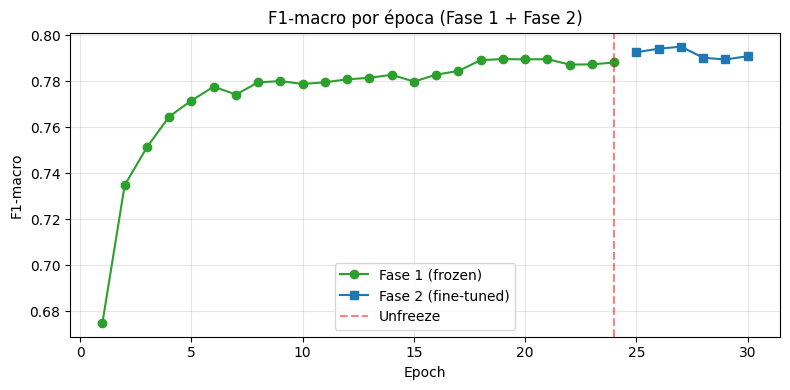


Mejor F1 global: 0.7949 (época 27)
Mejor Fase 1: 0.7895
Mejor Fase 2: 0.7949


In [10]:
import matplotlib.pyplot as plt

h1 = [(e["epoch"], e["eval_f1_macro"]) for e in trainer1.state.log_history if "eval_f1_macro" in e]
h2 = [(e["epoch"], e["eval_f1_macro"]) for e in trainer2.state.log_history if "eval_f1_macro" in e]
last_ep = h1[-1][0] if h1 else 0
h2_off = [(ep + last_ep, f1) for ep, f1 in h2]

fig, ax = plt.subplots(figsize=(8, 4))
if h1: ax.plot(*zip(*h1), "o-", label="Fase 1 (frozen)", color="#2ca02c")
if h2:
    ax.plot(*zip(*h2_off), "s-", label="Fase 2 (fine-tuned)", color="#1f77b4")
    ax.axvline(last_ep, color="red", ls="--", alpha=0.5, label="Unfreeze")
ax.set_xlabel("Epoch"); ax.set_ylabel("F1-macro")
ax.set_title("F1-macro por época (Fase 1 + Fase 2)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

all_f1 = h1 + h2_off
best_i = np.argmax([f for _, f in all_f1])
print(f"\nMejor F1 global: {all_f1[best_i][1]:.4f} (época {all_f1[best_i][0]:.0f})")
if h1: print(f"Mejor Fase 1: {max(f for _, f in h1):.4f}")
if h2: print(f"Mejor Fase 2: {max(f for _, f in h2):.4f}")


## 8. Guardado del modelo


In [11]:
MODEL_DIR = Path("models/red_neuronal_fasttext_bilstm_attention_v11")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

trainer2.save_model(str(MODEL_DIR))

import json, joblib
joblib.dump(vocab, MODEL_DIR / "vocab.joblib")

metadata = {
    "model": "FastText + BiLSTM + MultiHeadAttention v11",
    "framework": f"PyTorch {torch.__version__} + HuggingFace Trainer",
    "device": DEVICE_NAME,
    "vocab_size": VOCAB_SIZE, "embedding_dim": EMBEDDING_DIM,
    "lstm_units": [LSTM_UNITS_1, LSTM_UNITS_2],
    "att_heads": ATT_HEADS, "dense_units": DENSE_UNITS,
    "dropout_rate": DROPOUT_RATE,
    "learning_rate": LEARNING_RATE, "phase2_lr": PHASE2_LR,
    "batch_size": BATCH_SIZE,
    "dataset": "train_augmented_llm_balanced.csv",
    "preprocessing": "clean_classical (lematizaci\u00f3n)",
    "improvements": ["huggingface_trainer", "2_phase_unfreezing",
                     "oov_random_init", "reduced_dropout"],
    "seed": SEED,
}
with open(MODEL_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"Modelo guardado en {MODEL_DIR}")


Modelo guardado en models\red_neuronal_fasttext_bilstm_attention_v11


## 9. Submission a Kaggle


In [12]:
Path("submissions").mkdir(exist_ok=True)

preds_test = trainer2.predict(test_dataset)
y_test_pred = np.argmax(preds_test.predictions, axis=1)

sub = pd.DataFrame({"id": test_df["id"].values, "label": y_test_pred.astype(int)})
sp = "submissions/submission_red_neuronal_fasttext_bilstm_attention_v11.csv"
sub.to_csv(sp, index=False)

dist = sub["label"].value_counts(normalize=True).sort_index()
print(f"Guardado: {sp}  ({len(sub)} predicciones)")
print(f"Distribución: {', '.join(f'clase {k}: {v:.1%}' for k, v in dist.items())}")


c:\Users\agust\Desktop\TA047R-1C2026-GRUPO02\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Guardado: submissions/submission_red_neuronal_fasttext_bilstm_attention_v11.csv  (8500 predicciones)
Distribución: clase 0: 45.4%, clase 1: 14.7%, clase 2: 39.9%
